In [ ]:
import numpy as np
from scipy.integrate import RK45

def gravity(t, y):
    # y = [x, y, vx, vy]
    x, y_pos, vx, vy = y
    
    r = np.sqrt(x**2 + y_pos**2)
    
    ax = -x / r**3
    ay = -y_pos / r**3
    
    return np.array([vx, vy, ax, ay])


y0 = np.array([1.0, 0.0, 0.0, 1.0])  # circular orbit

solver = RK45(gravity, 0.0, y0, 20.0)

print(solver)

In [ ]:
import numpy as np
from scipy.integrate import RK45

# -----------------------------------
# Define your system: dy/dt = f(t, y)
# y is your state vector
# -----------------------------------
def f(t, y):
    # Example: simple harmonic oscillator
    # y = [x, v]
    x, v = y
    
    dxdt = v
    dvdt = -x
    
    return np.array([dxdt, dvdt])


# -----------------------------------
# Initial conditions
# -----------------------------------
t0 = 0.0
y0 = np.array([1.0, 0.0])   # initial position & velocity
t_end = 10.0


# -----------------------------------
# Create RK45 solver
# -----------------------------------
solver = RK45(
    fun=f,
    t0=t0,
    y0=y0,
    t_bound=t_end,
    max_step=0.1,      # optional
    rtol=1e-6,
    atol=1e-9
)


# -----------------------------------
# Step through integration manually
# -----------------------------------
t_values = [solver.t]
y_values = [solver.y.copy()]

while solver.status == 'running':
    solver.step()   # take one adaptive RK45 step
    
    t_values.append(solver.t)
    y_values.append(solver.y.copy())


# Convert to arrays
t_values = np.array(t_values)
y_values = np.array(y_values)

# Example: extract position and velocity
x_vals = y_values[:, 0]
v_vals = y_values[:, 1]

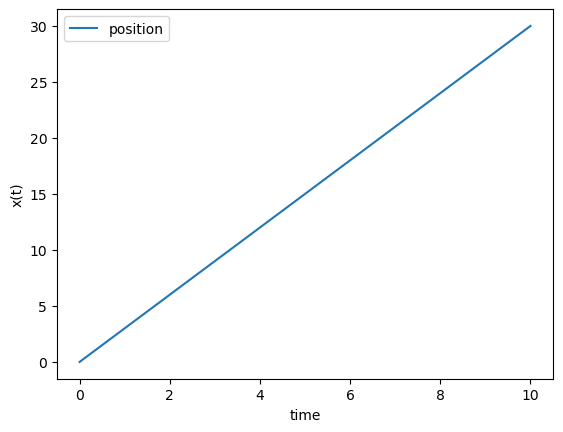

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# velocity function
def velocity(t):
    return 3.0   # constant velocity

# ODE: dx/dt = v(t)
def dxdt(t, x):
    return velocity(t)

# time span
t_span = (0, 10)

# initial position
x0 = [0.0]

# solve using RK45 automatically
sol = solve_ivp(
    fun=dxdt,
    t_span=t_span,
    y0=x0,
    method='RK45',
    t_eval=np.linspace(0, 10, 100)  # where you want output
)

# results
t = sol.t
x = sol.y[0]

# plot
plt.plot(t, x, label="position")
plt.xlabel("time")
plt.ylabel("x(t)")
plt.legend()
plt.show()